# **Exploração e análise de dados de crédito com SQL**

Esse notebook faz parte do curso SQL para análise de dados da EBAC

## **Os dados:**
Os dados representam informações de clientes de um banco e contam com as seguintes colunas:

* idade = idade do cliente
* sexo = sexo do cliente (F ou M)
* dependentes = número de dependentes dos clientes
* escolaridade = nível de escolaridade dos clientes
* estado_civil = estado civil dos clientes
* salario_anual = faixa salarial dos clientes
* tipo_cartao = tipo de cartão dos clientes
* qtd_produtos = quantidade de produtos comprados nos últimos 12 meses
* iteracoes_12m = quantidade de iterações/transações nos últimos 12 meses
* meses_inativo_12m = quantidade de meses que o cliente ficou inativo
* limite_credito = limite de crédito dos clientes
* valor_transacoes_12m = valor das transações dos últimos 12 meses
* qtd_transacoes_12m = quantidade de transações dos últimos 12 meses

A tabela foi criada no **AWS Athena** junto com o **S3 Bucket** com uma versão dos dados disponibilizados em:
https://github.com/andre-marcos-perez/ebac-course-units/tree/main/dataset

## **Exploração de dados:**
Primeiro vamos entender o que tem na nossa matéria prima. Vamos à exploração de dados:

**Qual a quantidade de informações que temos na nossa base de dados?**

Query: SELECT count(*) FROM credito

|     Resposta: 2564 linhas

**ps.:** A base de dados do link acima contém mais linhas do que a seleção utilizada. Para o propósito desta análise iremos utilizar apenas uma parcela dos dados disponíveis tendo em vista as limitações do uso gratuito do AWS Athena.

**Como são os dados**

Query: SELECT * FROM credito LIMIT 10;

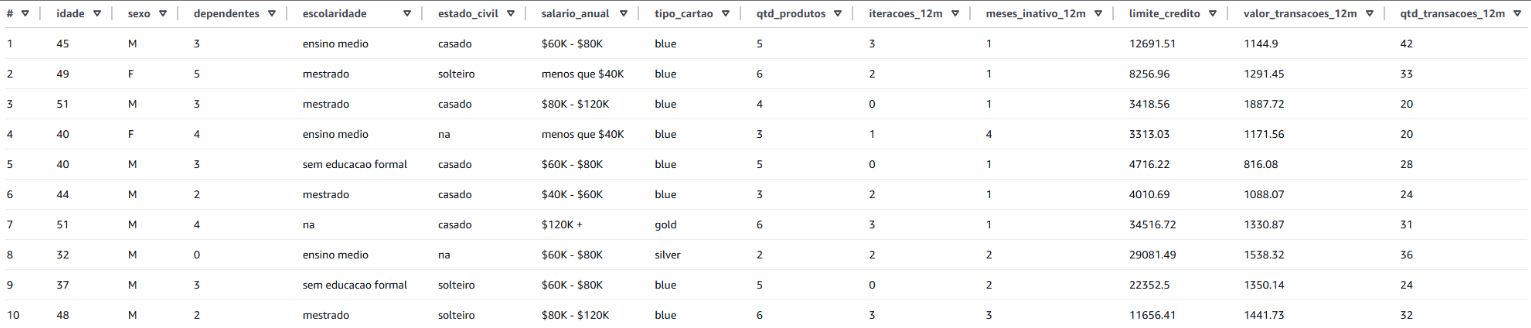

|     A partir deste código podemos observar que existem algumas informações nulas na tabela (valor na). Vamos analisar melhor os valores de cada coluna.

**Quais os tipos de cada dado**

Query: DESCRIBE credito

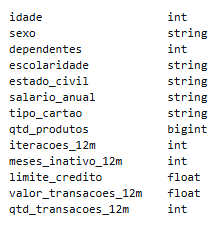

|     Agora que já entendemos quais são os tipos de dados, vamos olhar mais atentamente para as variáveis que não são numéricas.

**Quais são os tipos de escolaridade disponíveis no dataset?**

Query: SELECT DISTINCT escolaridade FROM credito

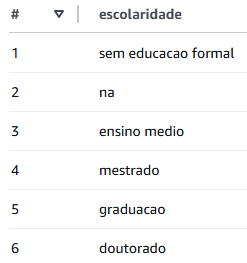

|     Os dados contam com vários níveis de escolaridade e é possível perceber que temos valores nulos (na) no dataset.

**Quais são os tipos de estado_civil disponíveis no dataset?**

Query: SELECT DISTINCT estado_civil FROM credito

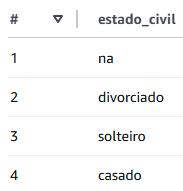

|     Podemos observar 3 tipos diferentes de estado civil, além do valor nulo (na).

**Quais são os tipos de salario_anual disponíveis no dataset?**

Query: SELECT DISTINCT salario_anual FROM credito

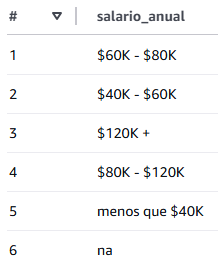

|     Temos 5 faixas salariais no nosso dataset, além do valor nulo (na).

**Quais são os tipos de cartão disponíveis no dataset?**

Query: SELECT DISTINCT tipo_cartao FROM credito

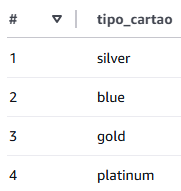

|     O banco oferece 5 tipos diferentes de cartão para os seus clientes e não há dados faltantes nesta coluna.
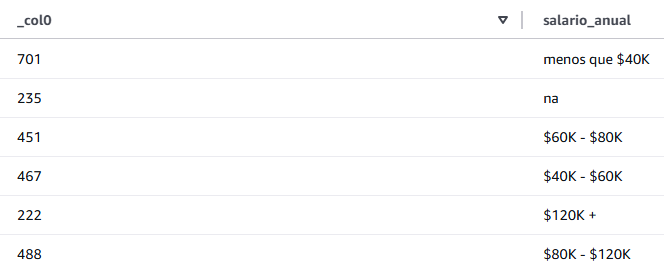
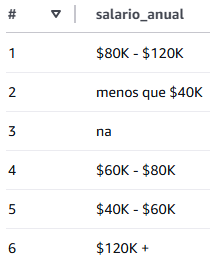
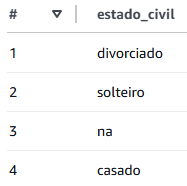
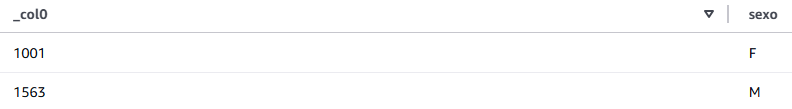
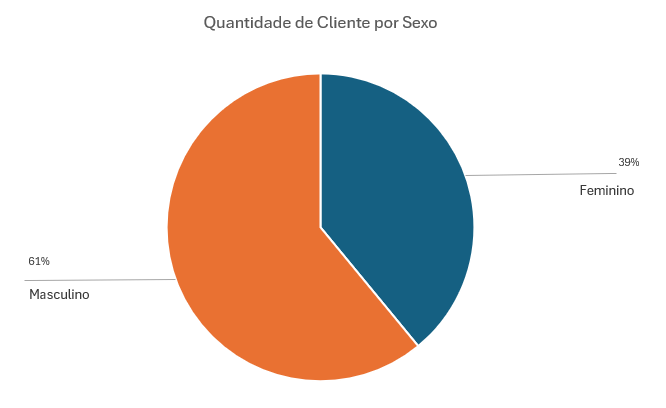
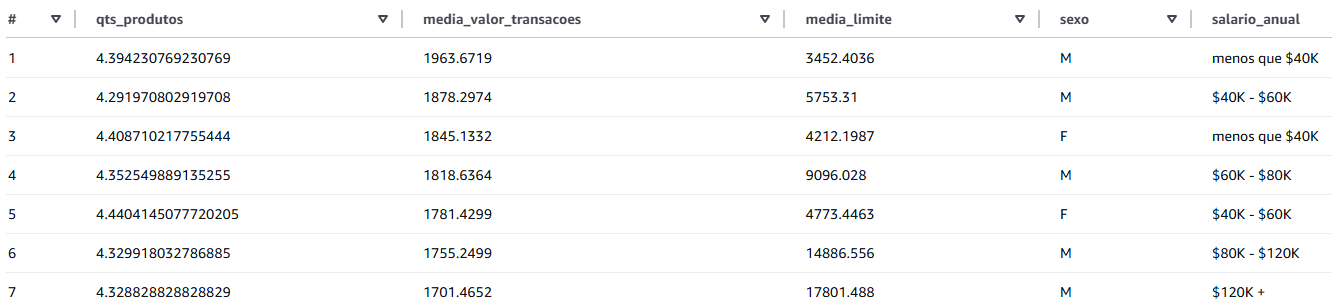
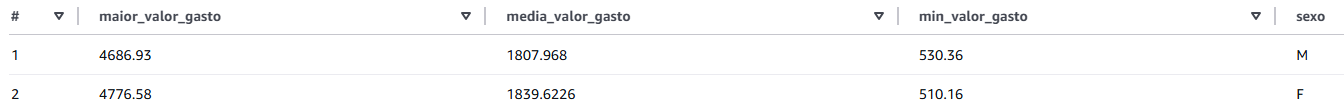
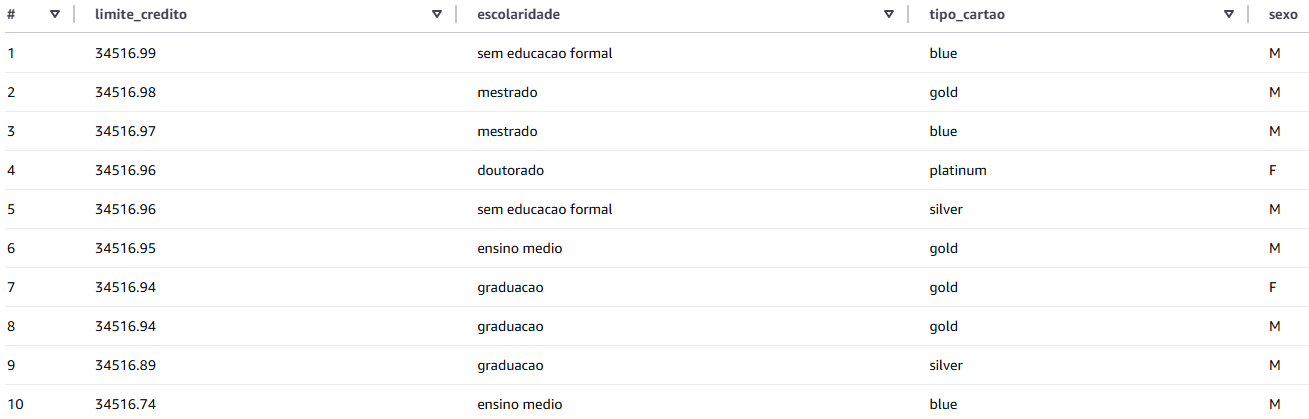

# **Análise de Dados**

Nesta etapa iniciamos o processo de análise dos dados propriamento dita para a geração de insights e hipóteses.


**Qual o número de clientes para cada tipo de faixa salarial?**

Query: SELECT COUNT(*), salario_anual FROM credito GROUP BY salario_anual

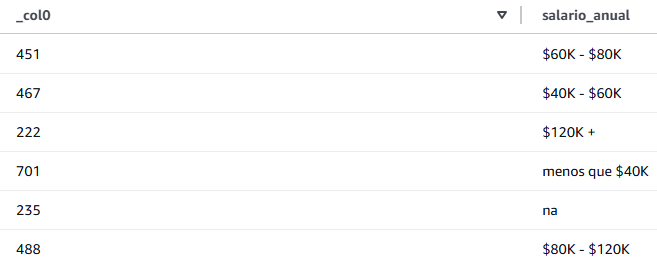

* O maior número de clientes possui faixa salarial de menos de 40 mil dólares ao ano
* O menor número de clientes pertence às pessoas com faixa salarial de mais de 120 mil dólares ao ano
* 235 clientes não informaram a faixa salarial

**Quaio número de clientes do sexo masculino e feminino encontrados no dataset?**

Query: SELECT COUNT(*), sexo FROM credito GROUP BY sexo

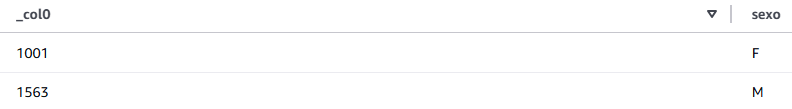

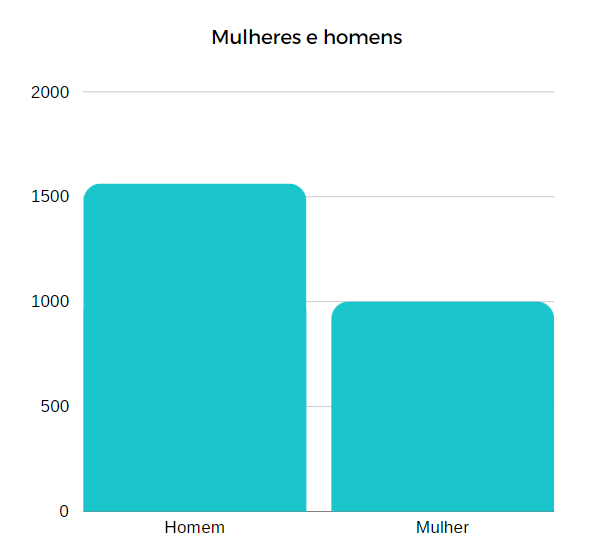

* Vemos que há um ocorrência maior de clientes do sexo masculino.

**Qual a idade dos clientes?**

Query: SELECT AVG(idade) AS media_idade, MIN(idade) AS min_idade, MAX(idade) AS max_idade, sexo FROM credito GROUP BY sexo

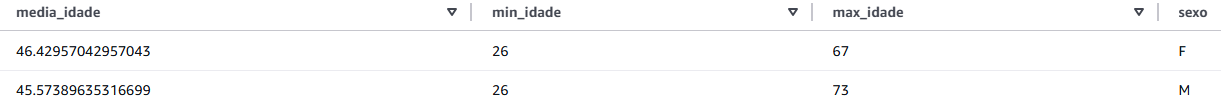

* A média de idade entre homens e mulheres é bem próxima
* O cliente mais novo tem 26 anos
* O cliente mais velho tem 73 anos

**Quais as características dos clientes que possuem os maiores creditos?**

Query:
SELECT MAX(limite_credito) AS limite_credito, escolaridade, tipo_cartao, sexo FROM credito

WHERE escolaridade != 'na' AND tipo_cartao != 'na' 

GROUP BY escolaridade, tipo_cartao, sexo 

ORDER BY limite_credito DESC

limit 10

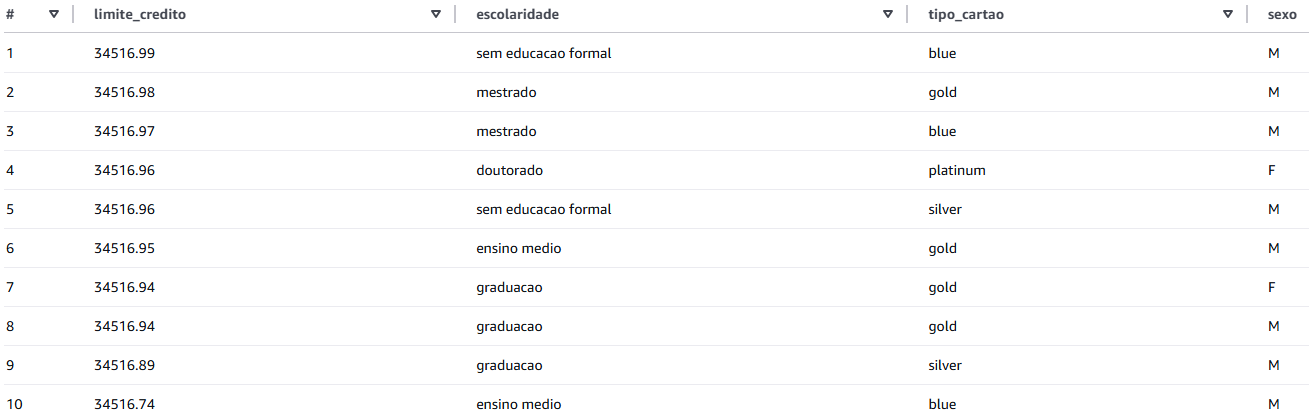

* Com este código podemos analisar que a escolaridade não possui impacto sobre o limite de crédito, pois o maior limite de crédito está direcionado a um cliente sem educação formal.
* O tipo de cartão também parece não estar relacionado ao limite, pois notamos que o maior limite é um cartão tipo blue.

**Quais as características dos clientes que possuem os menores creditos?**

Query:
SELECT MAX(limite_credito) AS limite_credito, escolaridade, tipo_cartao, sexo FROM credito

WHERE escolaridade != 'na' AND tipo_cartao != 'na'

GROUP BY escolaridade, tipo_cartao, sexo

ORDER BY limite_credito ASC

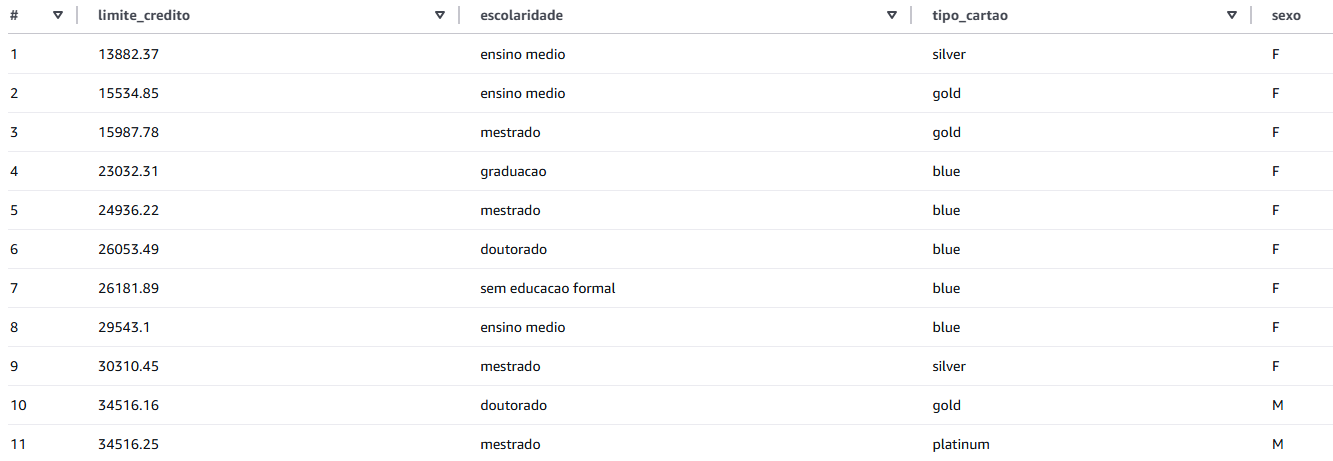

* Conseguimos perceber que entre os 10 menores limites de crédito não tem nenhum cartão platinum.
* Os menores limites de crédito são de mulheres

**Qual gênero gasta mais?**

Query:
select max(valor_transacoes_12m) as maior_valor_gasto, avg(valor_transacoes_12m) as media_valor_gasto, min(valor_transacoes_12m) as min_valor_gasto, sexo

from credito 

group by sexo

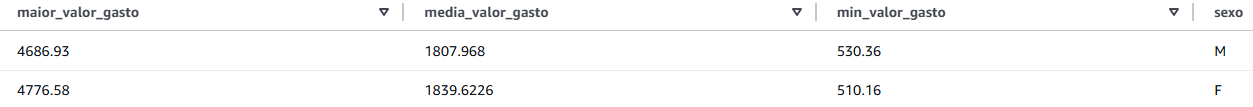

* A partir desta query podemos analisar que não há diferença relevante no valor gasto pelo sexo feminino e masculino.

**O salário impacta no limite?**

Query:
select avg(qtd_produtos) as qts_produtos, avg(valor_transacoes_12m) as media_valor_transacoes, avg(limite_credito) as media_limite, sexo, salario_anual from credito 

where salario_anual != 'na' 

group by sexo, salario_anual 

order by avg(valor_transacoes_12m) desc

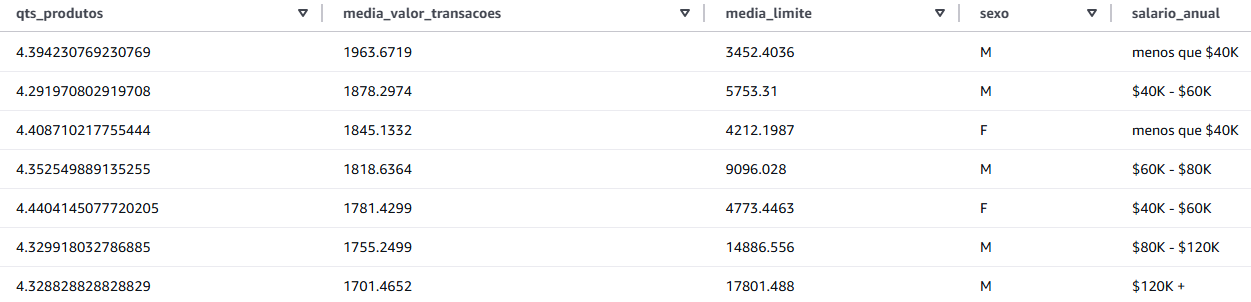

* Aqui podemos ver uma correlação entre a faixa salarial e o limite de crédito: quanto maior o salário, mais limite o banco concede.

**Mulheres recebem salários menores que homens?**

Query: SELECT COUNT(*), salario_anual, sexo FROM credito GROUP BY sexo, salario_anual;

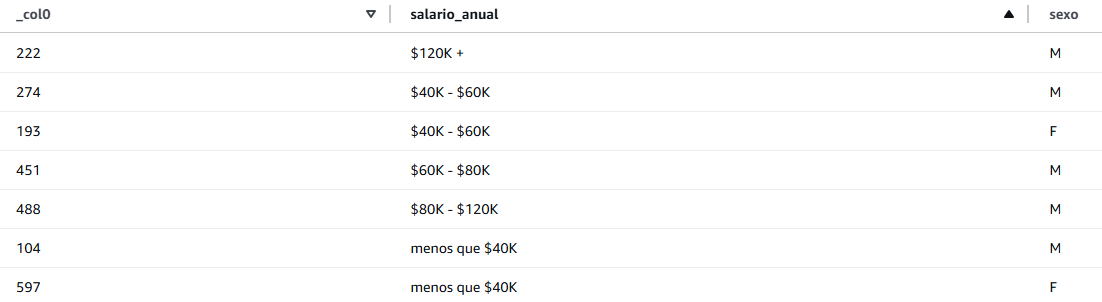

* Neste banco de dados mulheres recebem salários menores que homens, impactando diretamente no limete de crédito.

# **Conclusão**

A análise do dataset revelou insights importantes sobre a base de clientes e seus cartões de crédito, destacando disparidades de gênero significativas que demandam ações para promover equidade e inclusão.

* **Disparidade de Renda e Limite de Crédito:** Existe uma clara diferença salarial entre homens e mulheres, com as mulheres recebendo salários anuais consideravelmente menores. Essa disparidade se reflete nos limites de crédito, com os homens recebendo limites mais altos, independentemente da escolaridade.
* **Concentração de Renda:** A maioria dos clientes, independentemente do gênero, possui renda anual de até 40 mil, o que pode indicar a necessidade de produtos e serviços financeiros mais adequados a essa faixa de renda.

**Recomendações:**

* **Desenvolver Produtos para Faixas de Renda Específicas:** Criar produtos e serviços financeiros que atendam às necessidades da maioria dos clientes, que possuem renda anual de até 40 mil, como cartões com benefícios relevantes para essa faixa de renda e programas de educação financeira.
* **Revisão da Política de Limites de Crédito:** É crucial realizar uma análise aprofundada dos critérios utilizados para definir os limites de crédito, buscando eliminar vieses de gênero e garantir que as mulheres tenham acesso a limites justos e compatíveis com sua renda e perfil financeiro.

Ao implementar essas recomendações, a instituição financeira estará contribuindo para um sistema financeiro mais justo e inclusivo, oferecendo oportunidades iguais para todos os clientes, independentemente do gênero.